In [ ]:
!pip install opencv-python=="4.8.0.74" opencv-contrib-python=="4.5.5.64" --quiet

## Libraries

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive/')

Mounted at /content/gdrive/


In [ ]:
import cv2
import numpy as np

In [ ]:
import pandas as pd
import glob
import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from sklearn.metrics import average_precision_score, accuracy_score, recall_score, precision_score

## Load Models

In [ ]:
!wget https://raw.githubusercontent.com/kurnianggoro/GSOC2017/master/data/lbfmodel.yaml -O lbfmodel.yaml

--2024-11-14 15:43:22--  https://raw.githubusercontent.com/kurnianggoro/GSOC2017/master/data/lbfmodel.yaml
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 56375857 (54M) [text/plain]
Saving to: ‘lbfmodel.yaml’

lbfmodel.yaml       100%[===================>]  53.76M   194MB/s    in 0.3s    

2024-11-14 15:43:23 (194 MB/s) - ‘lbfmodel.yaml’ saved [56375857/56375857]



In [ ]:
# Face Detection
face_detector = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

In [ ]:
# Face Landmarks Detection
LBFmodel = "/content/lbfmodel.yaml"
landmark_detector = cv2.face.createFacemarkLBF()
landmark_detector.loadModel(LBFmodel)

## Functions

In [ ]:
def predict_faces(frame):
    """
    Predict faces coordenates in the input images
    """
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_detector.detectMultiScale(gray, 1.1, 4)
    return faces

In [ ]:
def predict_landmarks(frame, faces):
    """
    Predict landmarks for faces
    """
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    _, faces_landmarks = landmark_detector.fit(gray, np.array(faces))
    return faces_landmarks

In [ ]:
def crop_faces_by_landmarks_lbf(landmarks, frame=None, plot_point=False):
    """
    Crop faces by landmarks using LBF model
    """
    new_coord_faces = []
    eyes_nose_index  = list(range(27,48))

    for landmark in landmarks:
        x_eye_min = np.inf
        x_eye_max = 0
        y_nouse_max = 0
        x_min = np.inf
        y_min = np.inf
        x_max = 0
        y_max = 0
        for idx, (x, y) in enumerate(landmark[0]):
            if idx in eyes_nose_index:
                x_eye_min = min(x, x_eye_min)
                x_eye_max = max(x, x_eye_max)
                y_nouse_max = max(y, y_nouse_max)

            x_min = min(x, x_min)
            y_min = min(y, y_min)
            x_max = max(x, x_max)
            y_max = max(y, y_max)

            if plot_point and frame is not None:
                cv2.circle(frame, (int(x), int(y)), 1, (0, 255, 0), 2)

        diff_X_a = np.abs(x_min-x_eye_min)
        diff_X_b = np.abs(x_max-x_eye_max)
        diff_X = min(diff_X_a,diff_X_b)

        diff_Y = np.abs(y_max-y_nouse_max)

        x_new_min = max(0, x_min-diff_X)
        y_new_min = max(0, y_min-diff_Y)
        x_new_max = min(x_max+diff_X, frame.shape[1])
        y_new_max = y_max

        if plot_point and frame is not None:
            cv2.rectangle(frame, (int(x_new_min), int(y_new_min)), (int(x_new_max), int(y_new_max)), (0, 255, 0), 2)

        coord_head = [int(x_new_min), int(y_new_min), int(x_new_max), int(y_new_max)]
        new_coord_faces.append(coord_head)
    return new_coord_faces

## Load Dataset

In [ ]:
!cp "/content/gdrive/MyDrive/DATABASES/CelebAspoof/original_one_zip/CelebA_Spoof.zip" .
!unzip -qq CelebA_Spoof.zip

In [ ]:
!rm CelebA_Spoof.zip

In [ ]:
np.random.seed(2024)
df = pd.read_csv('/content/gdrive/MyDrive/DATABASES/CelebAspoof/face/ceas_faces_intradataset_loc.csv', index_col=False)
df['full_path_iqa'] = df['full_path_iqa'].apply(lambda x: x.replace('Data/', 'CelebA_Spoof/Data/'))
df.sample(3)

,frame,label,client,data_type,full_path_iqa,face_location_xyxy
342322,317806.jpg,spoof,5897,train,CelebA_Spoof/Data/train/5897/spoof/317806.jpg,"[234, 211, 348, 382]"
204323,066527.jpg,live,3381,train,CelebA_Spoof/Data/train/3381/live/066527.jpg,"[96, 82, 259, 343]"
213611,334178.jpg,spoof,3546,train,CelebA_Spoof/Data/train/3546/spoof/334178.jpg,"[174, 174, 384, 516]"


# Run Models

### Unit Test

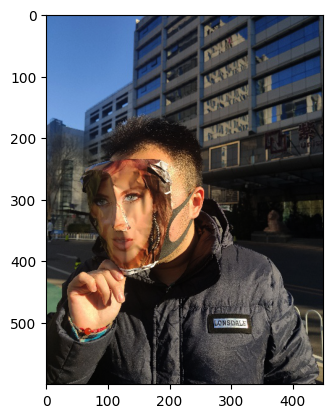

In [ ]:
img = cv2.imread(df.full_path_iqa[400])
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

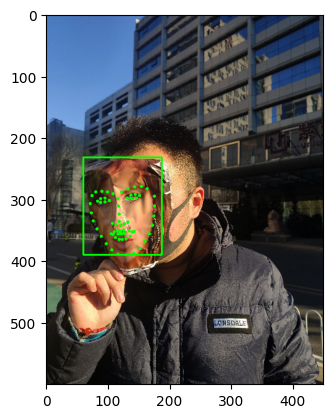

In [ ]:
faces = predict_faces(img)
landmarks = predict_landmarks(img, faces)
new_coord_faces = crop_faces_by_landmarks_lbf(landmarks, img, plot_point=True)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

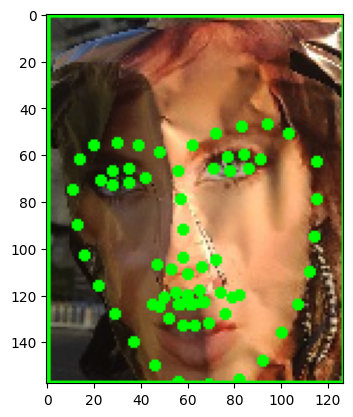

In [ ]:
for i_nc in new_coord_faces:
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)[i_nc[1]:i_nc[3],
                                                    i_nc[0]:i_nc[2],:])
    plt.show()

In [ ]:
%%timeit
faces = predict_faces(img)
landmarks = predict_landmarks(img)
new_coord_faces = crop_faces_by_landmarks_lbf(landmarks, img, plot_point=True)

484 ms ± 30.9 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


### For all imgs

In [ ]:
coordenates_list = []
for idx, row in tqdm.tqdm(df.iterrows(), total=df.shape[0]):
    new_coord_faces = ''
    try:
        img = cv2.imread(row.full_path_iqa)
        faces = predict_faces(img)
        if len(faces)>0:
            landmarks = predict_landmarks(img, faces)
            new_coord_faces = crop_faces_by_landmarks_lbf(landmarks, img, plot_point=False)[0]
        else:
            new_coord_faces = None
    except:
        new_coord_faces = 'error'

    coordenates_list.append(new_coord_faces)

len(coordenates_list)

In [ ]:
df['faces_coordenates'] = coordenates_list

In [ ]:
df.sample(3)

In [ ]:
path_csv = '/content/gdrive/MyDrive/PhD_Models/PhDresults/'
df.to_csv(f'{path_csv}FD_HaarCascade_CEAS_results.csv', index=False)

In [ ]:
df[df.faces_coordenates=='error'].shape[0], df[df.faces_coordenates==None].shape[0]

# Eval

### Functions


In [ ]:
def get_iou(pred_box, gt_box):

   pred_box = np.array(pred_box)
   gt_box = np.array(gt_box)

   ixmin = max(pred_box[0], gt_box[0])
   ixmax = min(pred_box[2], gt_box[2])
   iymin = max(pred_box[1], gt_box[1])
   iymax = min(pred_box[3], gt_box[3])

   iw = np.maximum(ixmax-ixmin+1., 0.)
   ih = np.maximum(iymax-iymin+1., 0.)

   inters = iw*ih

   uni = ((pred_box[2]-pred_box[0]+1.) * (pred_box[3]-pred_box[1]+1.) +
          (gt_box[2] - gt_box[0] + 1.) * (gt_box[3] - gt_box[1] + 1.) -
          inters)

   iou = inters / uni

   return iou

In [ ]:
def plot_face_squares(df, index):
    """Plots the ground truth and predicted face squares for a given image index."""

    row = df.iloc[index]
    img_path = row['full_path_iqa']
    try:
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    except Exception as e:
        print(f"Error reading image at {img_path}: {e}")
        return

    fig, ax = plt.subplots(1)
    ax.imshow(img)

    # Plot ground truth face square
    gt_coords = row['face_location_xyxy']
    gt_rect = patches.Rectangle((gt_coords[0], gt_coords[1]),
                                gt_coords[2]-gt_coords[0],
                                gt_coords[3]-gt_coords[1],
                                linewidth=2, edgecolor='g', facecolor='none')
    ax.add_patch(gt_rect)

    # Plot predicted face square
    if isinstance(row['faces_coordenates'], list):
        pred_coords = row['faces_coordenates']
        pred_rect = patches.Rectangle((pred_coords[0], pred_coords[1]),
                                        pred_coords[2]-pred_coords[0],
                                        pred_coords[3]-pred_coords[1],
                                        linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(pred_rect)


    plt.show()

### Evaluate

In [ ]:
df.face_location_xyxy = df.face_location_xyxy.apply(lambda x: eval(str(x)) if str(x)!='nan' else x)
df.head(3)

,frame,label,client,data_type,full_path_iqa,face_location_xyxy,faces_coordenates
0,496120.png,live,10001,test,Data/test/10001/live/496120.png,"[1265, 367, 1796, 1120]","[2034, 1915, 2140, 2015]"
1,497645.png,live,10001,test,Data/test/10001/live/497645.png,"[233, 104, 310, 200]","[209, 266, 246, 308]"
2,497900.png,live,10001,test,Data/test/10001/live/497900.png,"[303, 104, 397, 256]","[328, 217, 390, 285]"


In [ ]:
df.faces_coordenates.apply(lambda x: len(x) if str(x)!='nan' and str(x)!='error' else str(x)).value_counts()

,count
faces_coordenates,
4,475118
nan,86456
error,1


In [ ]:
iou_list = []
for idx, row in tqdm.tqdm(df.iterrows(), total=df.shape[0]):
    if isinstance(row['faces_coordenates'], list) and str(row['face_location_xyxy'])!='nan':
        if isinstance(row['faces_coordenates'][0], list):
            iou_list.append(max([get_iou(row['faces_coordenates'][i], row['face_location_xyxy']) for i in range(len(row['faces_coordenates']))]))
        else:
            iou_list.append(get_iou(row['faces_coordenates'], row['face_location_xyxy']))
    else:

        iou_list.append(0)

100%|██████████| 561575/561575 [01:38<00:00, 5711.56it/s]


In [ ]:
df['iou'] = iou_list

In [ ]:
df['correct_prediction'] = df.iou.apply(lambda x: 1 if x>=0.5 else 0)

In [ ]:
df.correct_prediction.value_counts()

,count
correct_prediction,
1,397291
0,164284


In [ ]:
df[['label', 'correct_prediction']].value_counts()

,,count
label,correct_prediction,
spoof,1,251719
live,1,145572
spoof,0,125449
live,0,38835


In [ ]:
y_true = (~df.face_location_xyxy.isnull()).astype(int).to_numpy()
y_pred = df.correct_prediction.to_numpy()

In [ ]:
print('AP:', average_precision_score(y_true, y_pred))

AP: 0.9999989581480901


In [ ]:
print('TPR (Recall):', recall_score(y_true, y_pred))

TPR (Recall): 0.7074610068504006


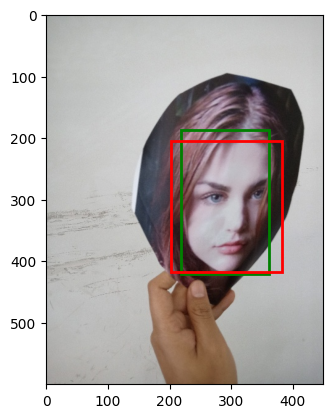

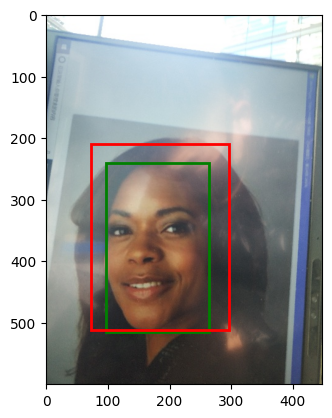

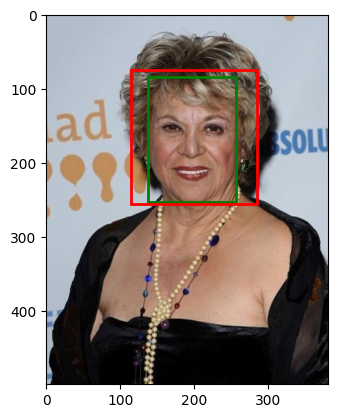

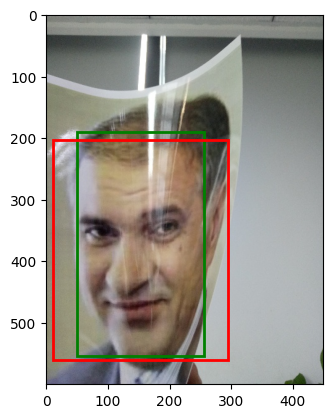

Label-Green
Predict-Red


In [ ]:
for i in np.random.randint(0, df.shape[0], 5):
    if df.iloc[i].correct_prediction==1:
        plot_face_squares(df, i)

print('Label-Green\nPredict-Red')

END